<a href="https://colab.research.google.com/github/zaku2590/classGCI/blob/main/FinalAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')


In [54]:
path = '/content/'

df = pd.read_csv(path + 'data.csv_')
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


In [55]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [56]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0
EnvironmentSatisfaction,0


In [57]:
df['Attrition'].value_counts(normalize=True)

,proportion
Attrition,
No,0.838095
Yes,0.161905


<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

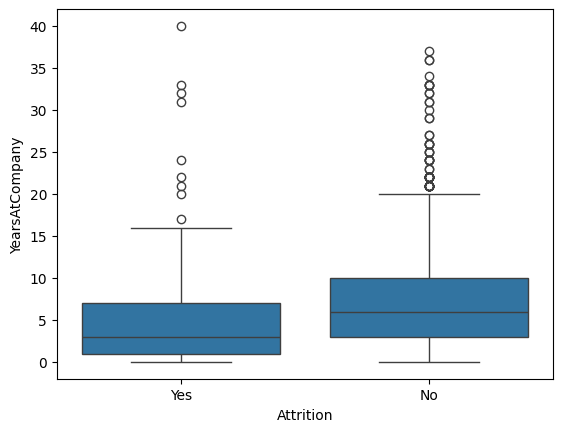

In [58]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)

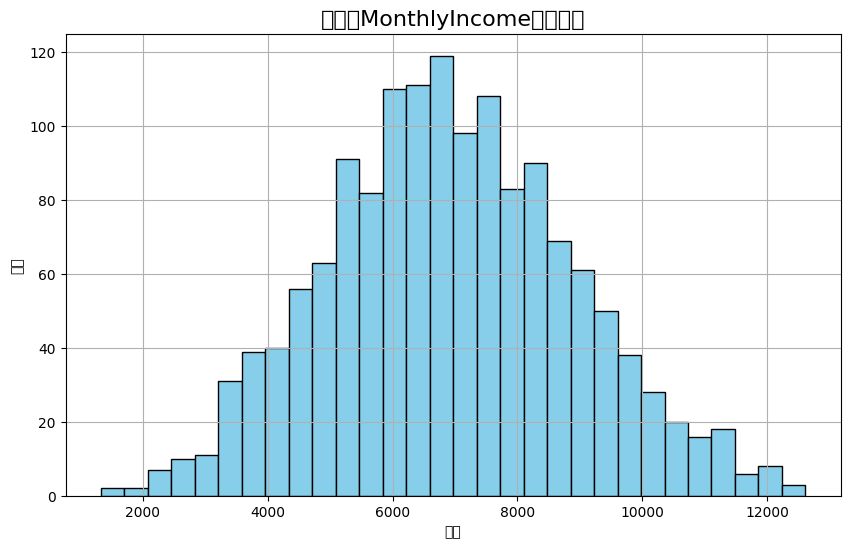

In [59]:
plt.figure(figsize=(10, 6))
plt.hist(df["MonthlyIncome"], bins=30, color="skyblue", edgecolor="black")
plt.title("月収（MonthlyIncome）の分布", fontsize=16)
plt.xlabel("月収")
plt.ylabel("人数")
plt.grid(True)
plt.show()

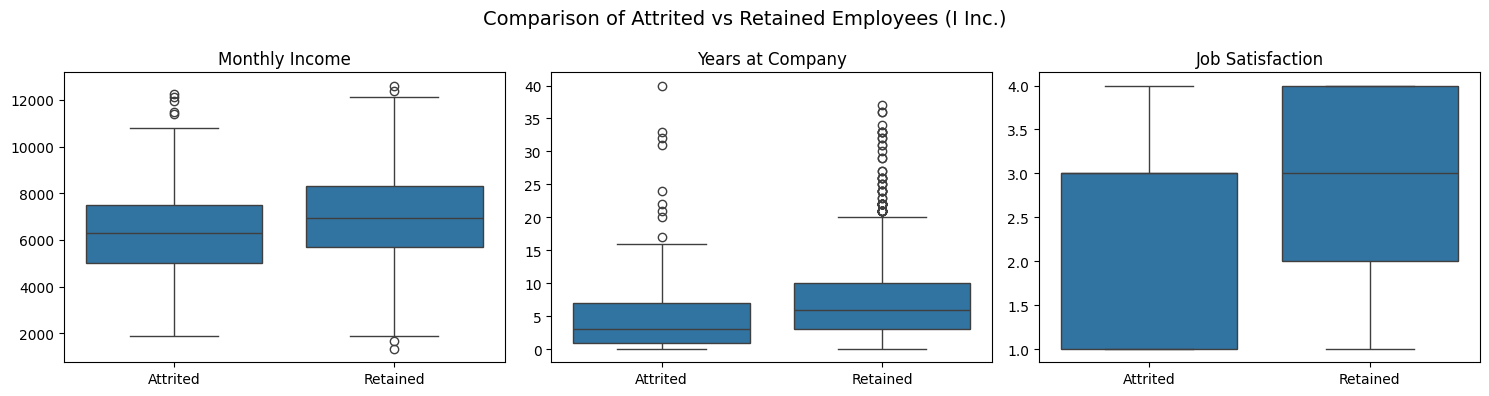

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# ラベル作成（英語）
df["AttritionLabel"] = df["Attrition"].map({"Yes": "Attrited", "No": "Retained"})

# グラフ描画
variables = ["MonthlyIncome", "YearsAtCompany", "JobSatisfaction"]
titles = ["Monthly Income", "Years at Company", "Job Satisfaction"]

plt.figure(figsize=(15, 4))

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x="AttritionLabel", y=var)
    plt.title(titles[i])
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Comparison of Attrited vs Retained Employees (I Inc.)", fontsize=14)
plt.tight_layout()
plt.show()


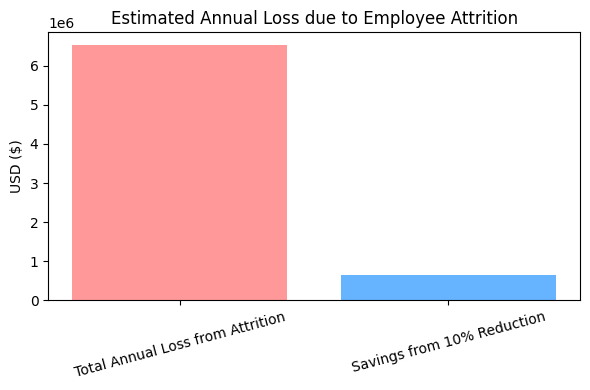

In [61]:
total_employees = len(df)
attrition_rate = (df["Attrition"] == "Yes").mean()
avg_annual_salary = df["MonthlyIncome"].mean() * 12
cost_per_attrition = avg_annual_salary * 0.33
num_attrited = int(total_employees * attrition_rate)
total_loss = cost_per_attrition * num_attrited
savings_10pct = total_loss * 0.1

labels = ['Total Annual Loss from Attrition', 'Savings from 10% Reduction']
values = [total_loss, savings_10pct]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors)
plt.title('Estimated Annual Loss due to Employee Attrition')
plt.ylabel('USD ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("離職コスト試算_グラフ.png")
plt.show()


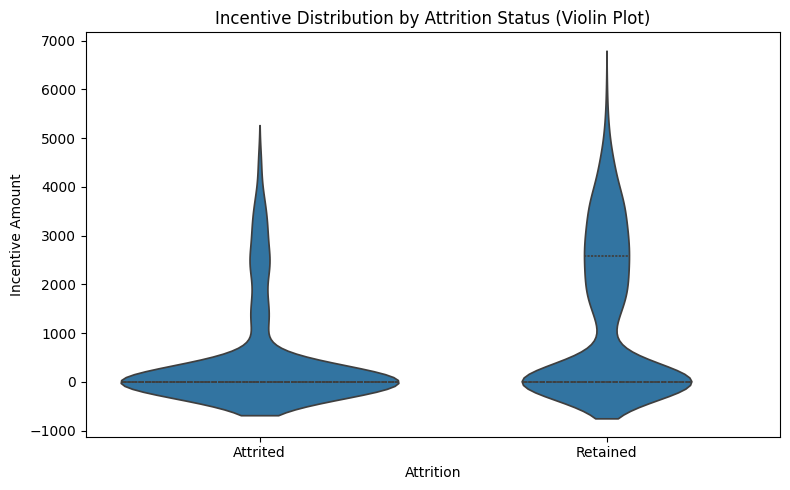

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="AttritionLabel", y="Incentive", inner="quartile")
plt.title("Incentive Distribution by Attrition Status (Violin Plot)")
plt.xlabel("Attrition")
plt.ylabel("Incentive Amount")
plt.tight_layout()
plt.show()


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from lightgbm import LGBMClassifier
import warnings

warnings.filterwarnings('ignore')

# データ読み込み
df = pd.read_csv("data.csv_")

# 新しい特徴量の作成
df["TenureRatio"] = df["YearsAtCompany"] / df["TotalWorkingYears"]
df["PromotionFrequency"] = df["YearsSinceLastPromotion"] / df["YearsAtCompany"]
df["SatisfactionScore"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"]
)

# Attritionのフラグ化
df = df[df["Attrition"].isin(["Yes", "No"])].copy()
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})

# 不要なカラムの削除
drop_cols = [
    "Attrition", "AttritionFlag", "EmployeeNumber", "Over18", "EmployeeCount",
    "StandardHours", "Year"
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

# 説明変数・目的変数
X = df.copy()
y = pd.read_csv("data.csv_")["Attrition"].map({"Yes": 1, "No": 0})  # 念のため元のCSVから再取得

# データ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Optunaで得られた最適パラメータを反映
best_params = {
    'num_leaves': 84,
    'max_depth': 8,
    'learning_rate': 0.09897525906072366,
    'n_estimators': 713,
    'subsample': 0.9242900387588009,
    'colsample_bytree': 0.64117619327068,
    'reg_alpha': 1.3985245373424495e-07,
    'reg_lambda': 1.0502719486378876e-08,
    'random_state': 42
}

# モデル学習
model = LGBMClassifier(**best_params)
model.fit(X_train, y_train)

# 予測と評価
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Accuracy: 0.8707482993197279
ROC-AUC: 0.820630081300813


In [69]:
!pip install optuna
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }
    model = LGBMClassifier(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=3).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial.params)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 9.8 MB/s eta 0:00:00


[I 2025-07-29 07:16:49,984] A new study created in memory with name: no-name-995377bb-9af4-4ecd-8152-b12cb531b7b7
[I 2025-07-29 07:16:50,986] Trial 0 finished with value: 0.7971027194446799 and parameters: {'num_leaves': 94, 'max_depth': 7, 'learning_rate': 0.0035748389863234794, 'n_estimators': 401, 'subsample': 0.9415150224439651, 'colsample_bytree': 0.9234408415308973, 'reg_alpha': 0.00033015809257975744, 'reg_lambda': 0.06499821685202402}. Best is trial 0 with value: 0.7971027194446799.
[I 2025-07-29 07:16:52,869] Trial 1 finished with value: 0.81139323828332 and parameters: {'num_leaves': 41, 'max_depth': 7, 'learning_rate': 0.012466934981616475, 'n_estimators': 765, 'subsample': 0.8771173011095632, 'colsample_bytree': 0.7440528464560296, 'reg_alpha': 2.0760902946580354e-06, 'reg_lambda': 1.1071787828995041e-05}. Best is trial 1 with value: 0.81139323828332.
[I 2025-07-29 07:16:54,750] Trial 2 finished with value: 0.795699705565499 and parameters: {'num_leaves': 64, 'max_depth': 6

Best trial:
{'num_leaves': 84, 'max_depth': 8, 'learning_rate': 0.09897525906072366, 'n_estimators': 713, 'subsample': 0.9242900387588009, 'colsample_bytree': 0.64117619327068, 'reg_alpha': 1.3985245373424495e-07, 'reg_lambda': 1.0502719486378876e-08}
